Hackaton FIAP

ETAPA 0:

Nessa etapa checamos GPU/CUDA para garantir treino rápido do Faster R-CNN.

Definimos a pasta BASE (com ou sem Google Drive) e cria: datasets/raw, datasets/voc, workdir, outputs.

Instala o Detectron2 (Faster R-CNN) e dependências básicas (OpenCV, etc.).

Valida o ambiente (mostra versões e se CUDA está ativo).

Resultado: ambiente pronto para a Etapa 1 (KB JSON) e, em seguida, baixar/organizar o dataset e treinar.

In [1]:
# === ETAPA 0 — Setup (Colab, dataset já no Drive) ======================
# Ajuste apenas os toggles/paths abaixo.
USE_DRIVE = True                              # usar Google Drive (recomendado)
DATASET_ZIP_NAME = "archive.zip"             # nome do ZIP em /stride_mvp/
DATASET_FOLDER_HINT = "src/dataset/dataset_augmented"  # se já estiver extraído

# 0) GPU
!nvidia-smi -L || echo "⚠️ Sem GPU? Ative 'GPU' em Runtime > Change runtime type"

import os, pathlib, platform

# 1) Drive + BASE (não remonta se já estiver montado)
if USE_DRIVE:
    try:
        from google.colab import drive
        if not os.path.isdir('/content/drive/MyDrive'):
            drive.mount('/content/drive')
            print("✅ Drive montado.")
        else:
            print("ℹ️ Drive já montado.")
        BASE = "/content/drive/MyDrive/stride_mvp"
    except Exception as e:
        print("⚠️ Erro ao montar o Drive, usando armazenamento local /content:", e)
        BASE = "/content/stride_mvp"
else:
    BASE = "/content/stride_mvp"

# 2) Pastas do projeto
DIRS = {
    "RAW":     f"{BASE}/datasets/raw",                 # zips/originais
    "VOC":     f"{BASE}/datasets/voc/VOC2007",
    "JPEG":    f"{BASE}/datasets/voc/VOC2007/JPEGImages",
    "ANN":     f"{BASE}/datasets/voc/VOC2007/Annotations",
    "SETS":    f"{BASE}/datasets/voc/VOC2007/ImageSets/Main",
    "WORKDIR": f"{BASE}/workdir",                      # treinos/logs/checkpoints
    "OUTPUTS": f"{BASE}/outputs",                      # relatórios/figuras/json
}
for p in DIRS.values():
    pathlib.Path(p).mkdir(parents=True, exist_ok=True)
print("📁 BASE =", BASE)

# 3) Detectron2 + deps (Faster R-CNN, VOC direto)
!pip -q install 'git+https://github.com/facebookresearch/detectron2.git' opencv-python matplotlib lxml tabulate tqdm

# 4) Sanidade do ambiente
import torch, detectron2
from detectron2.utils.collect_env import collect_env_info
print("🧠 PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available(), "| Python:", platform.python_version())
print("\n✅ Detectron2 instalado. Ambiente:\n", collect_env_info())

# 5) Checagem do dataset no Drive (sem extrair aqui)
zip_path  = f"{BASE}/{DATASET_ZIP_NAME}"
hint_path = f"{BASE}/{DATASET_FOLDER_HINT}"
print("\n🔎 Dataset no Drive:")
print(" - ZIP encontrado?        ", "✅" if os.path.exists(zip_path) else f"❌ (esperado: {zip_path})")

print("\n🎯 Etapa 0 concluída. Próximo: Etapa 2 (organizar em VOC + splits).")
# =============================================================================


GPU 0: Tesla T4 (UUID: GPU-82c96b13-1db0-3fac-a9f9-6775f5898477)
Mounted at /content/drive
✅ Drive montado.
📁 BASE = /content/drive/MyDrive/stride_mvp
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.1 MB/s eta 0:00:00
🧠 PyTorch: 2.8.0+cu126 | CUDA: True | Python: 3.12.11

✅ Detectron2 instalado. Ambiente:
 -------------------------------  -----------------------------------------------------------------
sys.platform                     linux
Python                           3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
numpy                            2.0.2
detectron2                       0.6 @/usr/local/lib/python3.12/dist-packages/detectron2
Compiler 

Etapa 1 — criar e salvar o KB (JSON)

Criamos um arquivo JSON com boas práticas de segurança por tipo de componente e por fluxo.

Ele serve para, depois da detecção, sugerir riscos (OWASP/CWE) e contramedidas automaticamente.

Contém: components (aliases, OWASP, CWE, controles) e dataflows (controles em trânsito).

Fica salvo em BASE/kb/controls.json.

O pipeline usa isso para gerar Arquitetura Entendida → Coerência → STRIDE.

In [2]:
# === ETAPA 1 — KB (componentes + dataflows) =====================
import os, json, pathlib

# Descobre BASE a partir da Etapa 0
BASE = globals().get("BASE", "/content/stride_mvp")
KB_DIR = f"{BASE}/kb"
pathlib.Path(KB_DIR).mkdir(parents=True, exist_ok=True)
KB_PATH = f"{KB_DIR}/controls.json"

KB = {
  "meta": {
    "version": "1.0",
    "description": "Knowledge base de controles por componente e dataflow (vendor-agnostic) com OWASP/CWE e aliases."
  },
  "components": {
    "ActorUser": {
      "aliases": ["user","client","browser","mobile","frontend"],
      "owasp": ["A07-Identification and Authentication Failures","A01-Broken Access Control"],
      "cwe": ["CWE-287","CWE-384"],
      "controls": [
        "MFA/2FA para contas sensíveis",
        "OIDC/OAuth2; sessões curtas; refresh tokens rotativos",
        "Proteção anti-bot/CAPTCHA; rate limit por IP/usuário"
      ]
    },
    "Internet": {
      "aliases": ["public","external","internet"],
      "owasp": ["A08-Software and Data Integrity Failures"],
      "cwe": ["CWE-918"],
      "controls": [
        "Expor apenas via Edge (CDN/WAF/Front Door)",
        "Ocultar origens; allowlist de origens quando possível",
        "TLS forte (TLS1.2+) para todo tráfego público"
      ]
    },
    "ZoneBoundary": {
      "aliases": ["vpc","vnet","subnet","dmz","resource group","rg"],
      "owasp": ["A05-Security Misconfiguration"],
      "cwe": ["CWE-284"],
      "controls": [
        "Separar subnets públicas/privadas; negar entrada direta",
        "Security Groups/NSG mínimos; egress control",
        "PrivateLink/Private Endpoint para serviços gerenciados"
      ]
    },
    "LoadBalancer": {
      "aliases": ["alb","nlb","elb","application gateway","ingress"],
      "owasp": ["A01-Broken Access Control","A05-Security Misconfiguration","A07-Auth Failures"],
      "cwe": ["CWE-346","CWE-287"],
      "controls": [
        "TLS1.2+ obrigatório; mTLS interno quando aplicável",
        "Rate limit/connection draining; health checks",
        "Headers de segurança (HSTS, CSP); redirecionar HTTP→HTTPS"
      ]
    },
    "APIGateway": {
      "aliases": ["api gateway","apim","api management","gateway"],
      "owasp": ["API1:2019 Broken Object Level Authorization","A05-Security Misconfiguration"],
      "cwe": ["CWE-285","CWE-639"],
      "controls": [
        "JWT/OIDC; autorização por recurso (RBAC/ABAC)",
        "Validação de schema (OpenAPI/JSON Schema)",
        "Quotas/rate limit; CORS restrito; mTLS interno"
      ]
    },
    "WAF": {
      "aliases": ["aws waf","azure waf","modsecurity","web application firewall"],
      "owasp": ["A03-Injection","A05-Security Misconfiguration"],
      "cwe": ["CWE-20"],
      "controls": [
        "Regras gerenciadas + custom; proteção a upload/SQLi/XSS",
        "Bot control/geo-block; proteção GraphQL/API",
        "Integração com SIEM/alertas"
      ]
    },
    "CDN": {
      "aliases": ["cloudfront","front door","cdn"],
      "owasp": ["A02-Cryptographic Failures","A05-Security Misconfiguration"],
      "cwe": ["CWE-319"],
      "controls": [
        "TLS forte; bloquear acesso direto à origem",
        "Hardening de cache keys; assinatura de URL",
        "DDoS/Shield; limitar métodos/headers expostos"
      ]
    },
    "DDoS": {
      "aliases": ["shield","ddos protection","front door ddos"],
      "owasp": [],
      "cwe": [],
      "controls": [
        "Proteção volumétrica; autoscaling",
        "Rate-limit upstream; challenge pages",
        "Monitorar picos e ativar mitigação automática"
      ]
    },
    "IAM": {
      "aliases": ["identity","entra","iam","cognito","rbac","abac"],
      "owasp": ["A07-Auth Failures","A01-Broken Access Control"],
      "cwe": ["CWE-798","CWE-522"],
      "controls": [
        "MFA; rotação de credenciais; políticas de senha",
        "RBAC/ABAC; conditions por rede/dispositivo",
        "Revisão periódica de acessos e chaves"
      ]
    },
    "KMS": {
      "aliases": ["kms","key vault","cmk","hsm"],
      "owasp": ["A02-Cryptographic Failures"],
      "cwe": ["CWE-321","CWE-522"],
      "controls": [
        "Criptografia at-rest; rotação de chaves",
        "Chaves gerenciadas por cliente (CMK) quando necessário",
        "Auditar uso de chaves; envelope encryption"
      ]
    },
    "Secrets": {
      "aliases": ["secrets manager","parameter store","key vault secrets"],
      "owasp": ["A02-Cryptographic Failures","A05-Security Misconfiguration"],
      "cwe": ["CWE-798","CWE-522"],
      "controls": [
        "Segredos fora do código; injeção por ambiente/runtime",
        "Rotação automática; acesso mínimo",
        "Auditoria de leitura/uso de segredos"
      ]
    },
    "AppServer": {
      "aliases": ["ec2","vm","vmss","app service","eks","aks","gke","ecs","fargate","container"],
      "owasp": ["A03-Injection","A05-Security Misconfiguration","A09-Logging and Monitoring Failures"],
      "cwe": ["CWE-89","CWE-22","CWE-434"],
      "controls": [
        "Prepared statements/ORM; sanitização de entrada",
        "Least-privilege nas roles; SBOM/patching",
        "Logs imutáveis; mascarar PII em logs"
      ]
    },
    "Function": {
      "aliases": ["lambda","cloud functions","azure functions","serverless"],
      "owasp": ["A05-Security Misconfiguration","A04-Insecure Design"],
      "cwe": ["CWE-400"],
      "controls": [
        "Timeout curto; limites de memória/concorrência",
        "Idempotência; retries com backoff; circuit breaker",
        "Permissões mínimas; segredos via vault"
      ]
    },
    "ContainerOrchestrator": {
      "aliases": ["eks","aks","gke","kubernetes","k8s"],
      "owasp": ["A05-Security Misconfiguration"],
      "cwe": ["CWE-269"],
      "controls": [
        "RBAC no cluster; image signing",
        "NetworkPolicies (pod-to-pod); mTLS (service mesh)",
        "Secrets externos; escaneamento de imagens"
      ]
    },
    "Workflow": {
      "aliases": ["step functions","logic apps","airflow","orchestrator"],
      "owasp": ["A04-Insecure Design"],
      "cwe": ["CWE-703"],
      "controls": [
        "Validação de entrada; retries com backoff",
        "Timeouts por etapa; compensação/transações",
        "Least-privilege nas integrações"
      ]
    },
    "DBRelational": {
      "aliases": ["rds","aurora","azure sql","postgres","mysql"],
      "owasp": ["A03-Injection","A02-Cryptographic Failures","A05-Sec Misconfiguration"],
      "cwe": ["CWE-89","CWE-306","CWE-522"],
      "controls": [
        "TLS em trânsito; criptografia at-rest (KMS/Key Vault)",
        "Usuário de app sem DDL; roles mínimas",
        "Backup/restore testado; audit logs; masking"
      ]
    },
    "DBNoSQL": {
      "aliases": ["dynamodb","cosmosdb","mongo","cassandra","bigtable"],
      "owasp": ["A05-Security Misconfiguration"],
      "cwe": ["CWE-284"],
      "controls": [
        "Validação de schema quando disponível",
        "Acesso por IAM; TTL; partições bem definidas",
        "Backup/snapshot criptografado"
      ]
    },
    "Cache": {
      "aliases": ["redis","elasticache","memcached"],
      "owasp": ["A05-Security Misconfiguration"],
      "cwe": ["CWE-284"],
      "controls": [
        "Autenticação/ACL; rede privada",
        "TTL e purga; evitar PII/segredos",
        "Proteção contra hot keys (rate-limit)"
      ]
    },
    "Search": {
      "aliases": ["elasticsearch","opensearch","solr"],
      "owasp": ["A05-Security Misconfiguration","A02-Cryptographic Failures"],
      "cwe": ["CWE-200"],
      "controls": [
        "RBAC; tráfego privado; TLS",
        "Mascaramento de campos sensíveis",
        "Snapshots criptografados"
      ]
    },
    "ObjectStorage": {
      "aliases": ["s3","blob","gcs"],
      "owasp": ["A02-Cryptographic Failures","A05-Security Misconfiguration"],
      "cwe": ["CWE-200","CWE-732"],
      "controls": [
        "Buckets privados; bloquear ACL pública",
        "KMS/Key Vault; URLs assinadas",
        "Políticas por prefixo; logs de acesso"
      ]
    },
    "FileStorage": {
      "aliases": ["efs","filestore","nfs","smb"],
      "owasp": ["A05-Security Misconfiguration"],
      "cwe": ["CWE-284"],
      "controls": [
        "Permissões por caminho; criptografia",
        "Antimalware; quotas",
        "Acesso via rede privada"
      ]
    },
    "QueueBus": {
      "aliases": ["sqs","service bus","pubsub","rabbitmq"],
      "owasp": ["A05-Security Misconfiguration"],
      "cwe": ["CWE-703"],
      "controls": [
        "DLQ configurada; idempotência",
        "Criptografia em trânsito/repouso",
        "Quotas/limites de throughput"
      ]
    },
    "EventStream": {
      "aliases": ["kafka","kinesis","event hubs"],
      "owasp": [],
      "cwe": [],
      "controls": [
        "TLS/mTLS; auth SASL/OAuth",
        "Quotas/retention; particionamento adequado",
        "Criptografia e isolamento de tenants"
      ]
    },
    "EmailNotification": {
      "aliases": ["ses","sendgrid","sns","push"],
      "owasp": ["A02-Cryptographic Failures","A05-Security Misconfiguration"],
      "cwe": ["CWE-201"],
      "controls": [
        "SPF/DKIM/DMARC; limitar envio",
        "Evitar PII em assunto/corpo; templates saneados",
        "Rotacionar chaves/API keys"
      ]
    },
    "Monitoring": {
      "aliases": ["cloudwatch","log analytics","grafana","siem"],
      "owasp": ["A09-Logging and Monitoring Failures"],
      "cwe": ["CWE-532"],
      "controls": [
        "Logs imutáveis; trilhas de auditoria",
        "Correlação trace/span; alertas",
        "Retenção e privacidade adequadas"
      ]
    },
    "BackupDR": {
      "aliases": ["aws backup","azure backup","vault"],
      "owasp": [],
      "cwe": [],
      "controls": [
        "Políticas de retenção; backup criptografado",
        "Testes periódicos de restore",
        "Cofres isolados (cross-account/region)"
      ]
    },
    "Networking": {
      "aliases": ["vpn","direct connect","expressroute","nat gw","privatelink","private endpoint"],
      "owasp": [],
      "cwe": [],
      "controls": [
        "IKEv2; criptografia forte; split-tunnel mínimo",
        "Rotas estritas; inspeção de egress",
        "Preferir endpoints privados para SaaS/serviços"
      ]
    },
    "CICD": {
      "aliases": ["codepipeline","github actions","azure devops","gitlab","argo"],
      "owasp": ["A08-Software and Data Integrity Failures"],
      "cwe": ["CWE-829"],
      "controls": [
        "Secrets no vault; revisão de PR",
        "SAST/DAST/deps scanning; SBOM/assinatura de artefatos",
        "Ambientes isolados; princípio do menor privilégio"
      ]
    },
    "IaC": {
      "aliases": ["terraform","cloudformation","bicep","pulumi"],
      "owasp": [],
      "cwe": [],
      "controls": [
        "Revisão de mudanças; scanners (tfsec/Checkov)",
        "Estados protegidos/backends seguros",
        "Políticas organizacionais (SCP/Blueprints)"
      ]
    },
    "Arrow": {
      "aliases": ["arrow","seta","dataflow","flow"],
      "owasp": [],
      "cwe": [],
      "controls": [
        "Indicar protocolo/porta quando possível",
        "Preferir TLS/mTLS; assinatura/HMAC",
        "Logs de acesso e correlação"
      ]
    }
  },
  "dataflows": {
    "Internet->Edge": {
      "owasp": ["A02-Crypto Failures","A05-Sec Misconfig"],
      "cwe": ["CWE-319"],
      "controls": [
        "TLS forte; bot/DDoS; header sanity",
        "Bloquear origem direta; CDN/WAF na borda"
      ]
    },
    "Edge->GatewayLB": {
      "owasp": ["A02","A05"],
      "cwe": [],
      "controls": [
        "mTLS entre Edge e Gateway/LB",
        "Rate limit/quotas; validação de headers"
      ]
    },
    "GatewayLB->App": {
      "owasp": ["A01","A07","A05"],
      "cwe": ["CWE-285","CWE-346"],
      "controls": [
        "AuthZ por rota; verificação de JWT no backend",
        "CORS restrito; headers de segurança",
        "Circuit breaker/timeouts"
      ]
    },
    "App->DBRelational": {
      "owasp": ["A03-Injection","A02","A05"],
      "cwe": ["CWE-89","CWE-306","CWE-522"],
      "controls": [
        "Prepared statements/ORM",
        "TLS em trânsito; KMS/Key Vault at-rest",
        "Usuário app sem DDL; audit logs"
      ]
    },
    "App->DBNoSQL": {
      "owasp": ["A05"],
      "cwe": ["CWE-284"],
      "controls": [
        "Validação de schema; IAM para acesso",
        "Backup/snapshot; TTL conforme domínio"
      ]
    },
    "App->Cache": {
      "owasp": ["A05"],
      "cwe": ["CWE-284"],
      "controls": [
        "Auth/ACL; TTL adequado; evitar PII",
        "Rate-limit para hot keys"
      ]
    },
    "App->ObjectStorage": {
      "owasp": ["A02","A05"],
      "cwe": ["CWE-200","CWE-732"],
      "controls": [
        "Buckets privados; URLs assinadas",
        "KMS/Key Vault; bloquear ACL pública"
      ]
    },
    "App<->SaaS_API": {
      "owasp": ["A02","A03","A09"],
      "cwe": [],
      "controls": [
        "Assinatura/HMAC; mTLS quando possível",
        "Retries com backoff; idempotência",
        "Logs correlacionados"
      ]
    },
    "App<->QueueBus": {
      "owasp": ["A05"],
      "cwe": ["CWE-703"],
      "controls": [
        "DLQ; idempotência; limites de throughput",
        "Criptografia e controle de acesso"
      ]
    },
    "CICD->App": {
      "owasp": ["A08-Software and Data Integrity Failures"],
      "cwe": ["CWE-829"],
      "controls": [
        "Secrets via vault; revisão de PR",
        "Assinatura de artefatos; deploy canário/blue-green"
      ]
    },
    "App<->EventStream": {
      "owasp": [],
      "cwe": [],
      "controls": [
        "TLS/mTLS; quotas; retenção adequada",
        "Isolamento por tópico/consumer group"
      ]
    }
  }
}

with open(KB_PATH, "w") as f:
    json.dump(KB, f, indent=2, ensure_ascii=False)
print(f"✅ KB salvo em: {KB_PATH}")
# ==============================================================================


✅ KB salvo em: /content/drive/MyDrive/stride_mvp/kb/controls.json


Etapa 2:

Baixamos e extraimos o dataset do Kaggle montado na etapa 0.
https://www.kaggle.com/datasets/carlosrian/software-architecture-dataset

Organiza no padrão VOC: VOC2007/JPEGImages, VOC2007/Annotations, VOC2007/ImageSets/Main.

Lê as classes dos XMLs e salva em classes.txt.

Cria os splits train/val/test sem vazamento (variações do mesmo original ficam juntas).

In [3]:
# === ETAPA 2 — extrai do ZIP só o necessário → VOC (/content) =========
import os, re, glob, zipfile, shutil, random, pathlib, xml.etree.ElementTree as ET, contextlib

# ---------- Parâmetros ----------
BASE = globals().get("BASE", "/content/drive/MyDrive/stride_mvp")  # onde está o ZIP
ZIP_CANDIDATES = [
    f"{BASE}/archive.zip",
    *glob.glob(f"{BASE}/archive*.zip"),
    *glob.glob(f"{BASE}/*.zip"),
]
SUBSET_GRUPOS = 400    # ex.: 200 para ~200 originais; None = tudo
PROGRESS_EVERY = 500    # log a cada N pares movidos
# --------------------------------

# Destinos rápidos no /content (não ocupa seu Drive)
EXTRACT   = "/content/_extract_fast"               # temporário
VOC_ROOT  = "/content/stride_cache/VOC2007"        # dataset final no padrão VOC
IMG_DIR   = f"{VOC_ROOT}/JPEGImages"
ANN_DIR   = f"{VOC_ROOT}/Annotations"
SET_DIR   = f"{VOC_ROOT}/ImageSets/Main"
for d in [EXTRACT, IMG_DIR, ANN_DIR, SET_DIR]:
    pathlib.Path(d).mkdir(parents=True, exist_ok=True)

# 1) Localizar ZIP
ZIP_CANDIDATES = [p for p in ZIP_CANDIDATES if os.path.exists(p)]
if not ZIP_CANDIDATES:
    raise SystemExit(f"⚠️ ZIP não encontrado em {BASE}. Coloque, por exemplo, {BASE}/archive.zip")
ZIP_PATH = sorted(ZIP_CANDIDATES, key=os.path.getmtime, reverse=True)[0]
print("📦 ZIP:", ZIP_PATH)

# 2) Ler índice do ZIP e filtrar apenas PNG/XML do dataset_augmented
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    all_names = z.namelist()

def is_target(name: str) -> bool:
    name_l = name.lower()
    return ("dataset_augmented/" in name_l) and (name_l.endswith(".png") or name_l.endswith(".xml"))

targets = [n for n in all_names if is_target(n)]
if not targets:
    raise SystemExit("❌ Não encontrei arquivos *.png/*.xml dentro de 'dataset_augmented/' no ZIP.")

# Garantir apenas pares válidos (PNG+XML com mesmo basename)
stems_png = {pathlib.Path(n).stem for n in targets if n.lower().endswith(".png")}
stems_xml = {pathlib.Path(n).stem for n in targets if n.lower().endswith(".xml")}
stems = sorted(stems_png & stems_xml)
if not stems:
    raise SystemExit("❌ Não há pares PNG+XML correspondentes no ZIP.")

# 3) Agrupar por “original” (sem vazamento): remove _aug_<n>
def original_key(stem: str) -> str:
    s = re.sub(r"_aug_\d+$", "", stem, flags=re.I)
    s = re.sub(r"[-_]?v\d+$", "", s, flags=re.I)
    s = re.sub(r"[-_]\d{1,3}$", "", s)
    return s

groups = {}
for s in stems:
    groups.setdefault(original_key(s), []).append(s)

keys = list(groups.keys())
random.seed(42); random.shuffle(keys)
if SUBSET_GRUPOS is not None:
    keys = keys[:min(SUBSET_GRUPOS, len(keys))]
print(f"🧮 Grupos (originais) selecionados: {len(keys)}")

# 4) Extrair apenas os arquivos necessários e mover para VOC
shutil.rmtree(EXTRACT, ignore_errors=True)
pathlib.Path(EXTRACT).mkdir(parents=True, exist_ok=True)

def member_path_for(stem: str, ext: str) -> str | None:
    pref = f"src/dataset/dataset_augmented/{stem}.{ext}"
    if pref in all_names:
        return pref
    cand = [n for n in all_names if n.endswith(f"/{stem}.{ext}")]
    return cand[0] if cand else None

moved = 0
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    for k in keys:
        for stem in groups[k]:
            png_member = member_path_for(stem, "png")
            xml_member = member_path_for(stem, "xml")
            if not png_member or not xml_member:
                continue
            out_png = os.path.join(IMG_DIR, f"{stem}.png")
            out_xml = os.path.join(ANN_DIR, f"{stem}.xml")
            if os.path.exists(out_png) and os.path.exists(out_xml):
                continue
            try:
                z.extract(png_member, EXTRACT)
                z.extract(xml_member, EXTRACT)
            except KeyError:
                continue
            src_png = os.path.join(EXTRACT, png_member)
            src_xml = os.path.join(EXTRACT, xml_member)
            pathlib.Path(IMG_DIR).mkdir(parents=True, exist_ok=True)
            pathlib.Path(ANN_DIR).mkdir(parents=True, exist_ok=True)
            if os.path.exists(src_png) and os.path.exists(src_xml):
                shutil.move(src_png, out_png)
                shutil.move(src_xml, out_xml)
                moved += 1
                subdir = os.path.dirname(src_png)
                with contextlib.suppress(Exception):
                    os.removedirs(subdir)
                if moved % PROGRESS_EVERY == 0:
                    print(f"   → {moved} pares movidos…", flush=True)

print(f"✅ Pares movidos para VOC: {moved}")

# 5) Gerar classes.txt lendo os XMLs no VOC
classes = set()
for xml_path in pathlib.Path(ANN_DIR).glob("*.xml"):
    try:
        t = ET.parse(xml_path)
        for obj in t.findall("object"):
            nm = (obj.find("name").text or "").strip()
            if nm: classes.add(nm)
    except Exception as e:
        print("⚠️ Erro em", xml_path.name, "→", e)

classes = sorted(classes)
pathlib.Path(f"{VOC_ROOT}/classes.txt").write_text("\n".join(classes), encoding="utf-8")
print(f"🧾 {len(classes)} classes detectadas.")

# 6) Criar splits (sem vazamento)
groups_voc = {}
for img in pathlib.Path(IMG_DIR).glob("*.png"):
    groups_voc.setdefault(original_key(img.stem), []).append(img.stem)

keys2 = list(groups_voc.keys()); random.seed(42); random.shuffle(keys2)
n = len(keys2); n_tr = int(0.8*n); n_val = int(0.1*n)
train_keys = set(keys2[:n_tr]); val_keys = set(keys2[n_tr:n_tr+n_val]); test_keys = set(keys2[n_tr+n_val:])

pathlib.Path(SET_DIR).mkdir(parents=True, exist_ok=True)
def write_split(name, keyset):
    out = os.path.join(SET_DIR, f"{name}.txt")
    with open(out, "w") as f:
        for k in sorted(keyset):
            for stem in sorted(groups_voc[k]):
                f.write(stem + "\n")
    return out

_ = write_split("train", train_keys)
_ = write_split("val",   val_keys)
_ = write_split("test",  test_keys)

# 7) Limpeza do extrato temporário
shutil.rmtree(EXTRACT, ignore_errors=True)

# 8) Resumo
num_png = len(list(pathlib.Path(IMG_DIR).glob("*.png")))
num_xml = len(list(pathlib.Path(ANN_DIR).glob("*.xml")))
print("\n📊 Resumo")
print(f"- VOC_ROOT: {VOC_ROOT}")
print(f"- PNG: {num_png} | XML: {num_xml}")
print(f"- Grupos (originais): {len(groups_voc)} → train:{len(train_keys)} val:{len(val_keys)} test:{len(test_keys)}")


📦 ZIP: /content/drive/MyDrive/stride_mvp/archive.zip
🧮 Grupos (originais) selecionados: 400
   → 500 pares movidos…
   → 1000 pares movidos…
   → 1500 pares movidos…
   → 2000 pares movidos…
   → 2500 pares movidos…
   → 3000 pares movidos…
   → 3500 pares movidos…
   → 4000 pares movidos…
✅ Pares movidos para VOC: 4090
🧾 93 classes detectadas.

📊 Resumo
- VOC_ROOT: /content/stride_cache/VOC2007
- PNG: 4090 | XML: 4090
- Grupos (originais): 400 → train:320 val:40 test:40


Etapa 3:

Lê o dataset VOC montado (pastas JPEGImages/, Annotations/, ImageSets/Main/).

Carrega as classes de classes.txt (se faltar, reconstrói a partir dos XMLs).

Registra os splits no Detectron2 com nomes:

arch_voc_train, arch_voc_val, arch_voc_test.

Valida o dataset: conta quantos exemplos há em cada split e checa consistência.

Mostra 2–3 imagens de exemplo com as caixas desenhadas (confirma que o Detectron2 está lendo certo).

In [4]:
# === ETAPA 3 — Registrar VOC aceitando .png/.jpg/.jpeg ==================
import os, pathlib, random, xml.etree.ElementTree as ET, cv2
from google.colab.patches import cv2_imshow
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.structures import BoxMode

# 1) onde está o VOC
VOC_ROOT = "/content/stride_cache/VOC2007"  # ajuste se você usou outro caminho
JPEG = os.path.join(VOC_ROOT,"JPEGImages")
ANN  = os.path.join(VOC_ROOT,"Annotations")
SETS = os.path.join(VOC_ROOT,"ImageSets/Main")
assert os.path.isdir(JPEG) and os.path.isdir(ANN) and os.path.isdir(SETS), "Pastas VOC faltando."

# 2) classes
CLASSES_TXT = os.path.join(VOC_ROOT, "classes.txt")
CLASS_NAMES = [ln.strip() for ln in open(CLASSES_TXT, encoding="utf-8") if ln.strip()]
assert CLASS_NAMES, "classes.txt vazio."
CLASS_TO_ID = {c:i for i,c in enumerate(CLASS_NAMES)}

# 3) loader compatível com várias extensões
def load_voc_anyext(dirname, split, class_names):
    split_file = os.path.join(dirname, "ImageSets", "Main", f"{split}.txt")
    stems = [ln.strip() for ln in open(split_file) if ln.strip()]
    dataset_dicts = []
    for idx, stem in enumerate(stems):
        # tenta .png, .jpg, .jpeg
        img_path = None
        for ext in (".png", ".jpg", ".jpeg"):
            p = os.path.join(dirname, "JPEGImages", stem + ext)
            if os.path.exists(p):
                img_path = p
                break
        if img_path is None:
            # pula itens que não têm imagem
            # print(f"[skip] imagem não encontrada para {stem}")
            continue
        xml_path = os.path.join(dirname, "Annotations", stem + ".xml")
        if not os.path.exists(xml_path):
            # pula itens sem xml
            # print(f"[skip] xml não encontrado para {stem}")
            continue

        record = {
            "file_name": img_path,
            "image_id": idx,
            "annotations": [],
        }

        try:
            root = ET.parse(xml_path).getroot()
            # tenta pegar tamanho do XML (opcional)
            size = root.find("size")
            if size is not None and size.find("width") is not None and size.find("height") is not None:
                record["width"]  = int(float(size.find("width").text))
                record["height"] = int(float(size.find("height").text))
        except Exception:
            pass

        for obj in root.findall("object"):
            name = (obj.findtext("name") or "").strip()
            if name not in CLASS_TO_ID:
                continue
            bb = obj.find("bndbox")
            if bb is None:
                continue
            try:
                x1 = int(float(bb.findtext("xmin"))); y1 = int(float(bb.findtext("ymin")))
                x2 = int(float(bb.findtext("xmax"))); y2 = int(float(bb.findtext("ymax")))
            except Exception:
                continue
            # sanity
            if x2 <= x1 or y2 <= y1:
                continue
            ann = {
                "bbox": [x1, y1, x2, y2],
                "bbox_mode": BoxMode.XYXY_ABS,
                "category_id": CLASS_TO_ID[name],
                "iscrowd": 0,
            }
            record["annotations"].append(ann)

        if record["annotations"]:
            dataset_dicts.append(record)

    return dataset_dicts

# 4) registrar splits com o loader custom
def register_split_custom(name, split):
    DatasetCatalog.register(name, lambda d=VOC_ROOT, s=split: load_voc_anyext(d, s, CLASS_NAMES))
    MetadataCatalog.get(name).set(thing_classes=CLASS_NAMES)

for nm, sp in [("arch_voc_train_png","train"), ("arch_voc_val_png","val"), ("arch_voc_test_png","test")]:
    if nm in DatasetCatalog.list():
        DatasetCatalog.remove(nm)  # permite re-registrar sem reiniciar a runtime
    register_split_custom(nm, sp)

# 5) checagem
train_set = DatasetCatalog.get("arch_voc_train_png")
val_set   = DatasetCatalog.get("arch_voc_val_png")
test_set  = DatasetCatalog.get("arch_voc_test_png")
print(f"📊 Splits — train:{len(train_set)}  val:{len(val_set)}  test:{len(test_set)}")

# 6) visualizar até 3 exemplos do train
k = min(3, len(train_set))
for rec in random.sample(train_set, k=k):
    img = cv2.imread(rec["file_name"])
    if img is None:
        print("⚠️ imread falhou para", rec["file_name"])
        continue
    # desenhar caixas simples (sem Visualizer, para ser à prova de falhas)
    for ann in rec["annotations"]:
        x1,y1,x2,y2 = map(int, ann["bbox"])
        cls = CLASS_NAMES[ann["category_id"]]
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(img, cls[:18], (x1, max(15,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1, cv2.LINE_AA)
    print(f"🖼️ {os.path.basename(rec['file_name'])} — objs: {len(rec['annotations'])}")
    cv2_imshow(img)

print("✅ Etapa 3 (fix) concluída — dataset lido com .png/.jpg/.jpeg.")


Output hidden; open in https://colab.research.google.com to view.

Debug da etapa 3

In [5]:
# 3-debug — comparar RAW vs OVERLAY para um exemplo
import os, random, pathlib, xml.etree.ElementTree as ET, cv2
from google.colab.patches import cv2_imshow

VOC_ROOT = "/content/stride_cache/VOC2007"   # ajuste se mudou
JPEG = f"{VOC_ROOT}/JPEGImages"; ANN = f"{VOC_ROOT}/Annotations"

# defina um stem específico se quiser (sem extensão). Ex: STEM = "aws_amazon_api_gateway_0000_aug_3"
STEM = None

stems = sorted({p.stem for p in pathlib.Path(JPEG).glob("*.png")} & {p.stem for p in pathlib.Path(ANN).glob("*.xml")})
if not stems: raise SystemExit("Sem imagens no VOC_ROOT.")
if STEM is None: STEM = random.choice(stems)
print("Stem escolhido:", STEM)

img_path = os.path.join(JPEG, STEM + ".png")
xml_path = os.path.join(ANN,  STEM + ".xml")
img_raw  = cv2.imread(img_path)
if img_raw is None: raise SystemExit("imread falhou: " + img_path)

# desenha caixas simples
img_box = img_raw.copy()
n_objs = 0
root = ET.parse(xml_path).getroot()
for obj in root.findall("object"):
    name = (obj.findtext("name") or "").strip()
    bb = obj.find("bndbox")
    if bb is None: continue
    x1 = int(float(bb.findtext("xmin"))); y1 = int(float(bb.findtext("ymin")))
    x2 = int(float(bb.findtext("xmax"))); y2 = int(float(bb.findtext("ymax")))
    if x2 <= x1 or y2 <= y1: continue
    n_objs += 1
    cv2.rectangle(img_box, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(img_box, name[:18], (x1, max(15,y1-4)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1, cv2.LINE_AA)

print(f"Objetos no XML: {n_objs}")
print("RAW (sem overlay):")
cv2_imshow(img_raw)
print("OVERLAY (com caixas):")
cv2_imshow(img_box)


Output hidden; open in https://colab.research.google.com to view.

Etapa 4:

Treinar um detector Faster R-CNN (Detectron2, ResNet-50 FPN) usando o dataset VOC que você montado.

Transfer learning (parte de pesos COCO) → aprende mais rápido.

Salva checkpoints e métricas numa pasta workdir e faz validação.

No fim, roda inferencia de teste e mostra 3 previsões com caixas.

In [6]:
# === ETAPA 4 — Treinar Faster R-CNN + avaliação VOC (mAP) =====================
# Saídas em OUT_DIR: metrics.json (com APs), model_final.pth, config.yaml

import os, time, json, xml.etree.ElementTree as ET
from pathlib import Path
from PIL import Image

import torch
from detectron2.structures import BoxMode
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.engine import DefaultTrainer
from detectron2.evaluation import PascalVOCDetectionEvaluator
from detectron2.config import get_cfg
from detectron2 import model_zoo

# -------------------- caminhos/base --------------------
VOC_ROOT = globals().get("VOC_ROOT", "/content/stride_cache/VOC2007")
IMG_DIR  = f"{VOC_ROOT}/JPEGImages"
ANN_DIR  = f"{VOC_ROOT}/Annotations"
SET_DIR  = f"{VOC_ROOT}/ImageSets/Main"

assert Path(IMG_DIR).exists() and Path(ANN_DIR).exists() and Path(SET_DIR).exists(), \
    f"VOC2007 inválido em {VOC_ROOT} (faltam JPEGImages/Annotations/ImageSets/Main)."

RUN_BASE = "/content/drive/MyDrive/stride_mvp/workdir"
os.makedirs(RUN_BASE, exist_ok=True)
STAMP   = int(time.time())
OUT_DIR = f"{RUN_BASE}/frcnn_run_{STAMP}"
os.makedirs(OUT_DIR, exist_ok=True)

print("📁 VOC_ROOT:", VOC_ROOT)
print("📁 OUT_DIR :", OUT_DIR)

# -------------------- classes --------------------
classes_txt = Path(VOC_ROOT) / "classes.txt"
if classes_txt.exists():
    CLASSES = [c.strip() for c in classes_txt.read_text().splitlines() if c.strip()]
else:
    cs = set()
    for p in Path(ANN_DIR).glob("*.xml"):
        try:
            t = ET.parse(p)
            for obj in t.findall("object"):
                nm = (obj.find("name").text or "").strip()
                if nm: cs.add(nm)
        except Exception:
            pass
    CLASSES = sorted(cs)

assert len(CLASSES) > 0, "Nenhuma classe encontrada (classes.txt ou Annotations)."
print(f"🧾 {len(CLASSES)} classes (primeiras): {', '.join(CLASSES[:10])}{'...' if len(CLASSES)>10 else ''}")

class_to_id = {c:i for i,c in enumerate(CLASSES)}

# -------------------- util: ler splits VOC --------------------
def _read_ids(split):
    f = Path(SET_DIR) / f"{split}.txt"
    assert f.exists(), f"Split '{split}' não encontrado: {f}"
    return [l.strip() for l in f.read_text().splitlines() if l.strip()]

train_ids = _read_ids("train")
val_ids   = _read_ids("val")
print(f"📊 Splits — train:{len(train_ids)}  val:{len(val_ids)}")

# -------------------- criar D2 dicts --------------------
def _load_split(ids):
    dds = []
    for iid in ids:
        img_path = str(Path(IMG_DIR) / f"{iid}.png")
        ann_path = Path(ANN_DIR) / f"{iid}.xml"
        if not ann_path.exists():
            continue
        try:
            t = ET.parse(ann_path)
            root = t.getroot()

            size = root.find("size")
            if size is not None:
                w = int(size.find("width").text)
                h = int(size.find("height").text)
            else:
                with Image.open(img_path) as im:
                    w, h = im.size

            annos = []
            for obj in root.findall("object"):
                nm = (obj.find("name").text or "").strip()
                if nm not in class_to_id:
                    continue
                bnd = obj.find("bndbox")
                if bnd is None:
                    continue
                x1 = float(bnd.find("xmin").text); y1 = float(bnd.find("ymin").text)
                x2 = float(bnd.find("xmax").text); y2 = float(bnd.find("ymax").text)
                annos.append({
                    "bbox": [x1, y1, x2, y2],
                    "bbox_mode": BoxMode.XYXY_ABS,
                    "category_id": class_to_id[nm],
                    "iscrowd": 0
                })

            dds.append({
                "file_name": img_path,
                "image_id": iid,
                "height": h,
                "width": w,
                "annotations": annos
            })
        except Exception:
            continue
    return dds

# -------------------- registrar datasets (nomes únicos) -----------------------
ds_train = f"arch_voc_train_png_{STAMP}"
ds_val   = f"arch_voc_val_png_{STAMP}"

for nm, ids, split_name in [(ds_train, train_ids, "train"), (ds_val, val_ids, "val")]:
    if nm in DatasetCatalog.list():
        DatasetCatalog.remove(nm)
    DatasetCatalog.register(nm, lambda ids=ids: _load_split(ids))
    MetadataCatalog.get(nm).set(
        thing_classes=CLASSES,
        dirname=VOC_ROOT,     # raiz com Annotations/, JPEGImages/, ImageSets/
        year=2007,
        split=split_name,
        evaluator_type="pascal_voc"
    )
print("✅ Datasets prontos:", ds_train, ds_val)

# -------------------- configuração do modelo --------------------
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
)

cfg.DATASETS.TRAIN = (ds_train,)
cfg.DATASETS.TEST  = (ds_val,)
cfg.DATALOADER.FILTER_EMPTY_ANNOTATIONS = True

cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 800
cfg.SOLVER.STEPS = []
cfg.SOLVER.WARMUP_ITERS = 0
cfg.SOLVER.CLIP_GRADIENTS.ENABLED = False

cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(CLASSES)
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ANCHOR_GENERATOR.SIZES = [[32, 64, 128, 256, 512]]

cfg.INPUT.MIN_SIZE_TRAIN = (640, 672, 704, 736, 768, 800)
cfg.INPUT.MIN_SIZE_TEST  = 800
cfg.INPUT.MAX_SIZE_TEST  = 1333

# ---- AMP compat: habilita se a sua versão suportar, senão segue em FP32
amp_enabled = False
try:
    cfg.AMP.ENABLED = True          # detectron2 mais novo
    amp_enabled = True
except Exception:
    try:
        cfg.SOLVER.AMP.ENABLED = True  # algumas versões expõem aqui
        amp_enabled = True
    except Exception:
        pass  # sem AMP nesta versão

cfg.TEST.EVAL_PERIOD = 200
cfg.OUTPUT_DIR = OUT_DIR
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Salva config.yaml (útil para a Etapa 5)
with open(os.path.join(OUT_DIR, "config.yaml"), "w") as f:
    f.write(cfg.dump())

# -------------------- Trainer custom com avaliador VOC ------------------------
class Trainer(DefaultTrainer):
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, f"eval_{dataset_name}")
        Path(output_folder).mkdir(parents=True, exist_ok=True)
        return PascalVOCDetectionEvaluator(dataset_name)

# -------------------- roda treino --------------------
print("\n🚀 Treinando")
print(f"- OUT_DIR : {OUT_DIR}")
print(f"- DATASET : {ds_train} | CLASSES: {len(CLASSES)}")
print(f"- MAX_ITER: {cfg.SOLVER.MAX_ITER} | BATCH_IMS: {cfg.SOLVER.IMS_PER_BATCH} | AMP: {amp_enabled}")
trainer = Trainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

print("\n✅ Etapa 4 finalizada.")
print("📦 Pesos:", os.path.join(OUT_DIR, "model_final.pth"))
print("⚙️ Config:", os.path.join(OUT_DIR, "config.yaml"))
print("📝 Métricas: metrics.json dentro de", OUT_DIR)
# ==============================================================================


📁 VOC_ROOT: /content/stride_cache/VOC2007
📁 OUT_DIR : /content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609
🧾 93 classes (primeiras): api, aws_amazon_api_gateway, aws_amazon_cloudfront, aws_amazon_cloudwatch, aws_amazon_dynamodb, aws_amazon_ec2, aws_amazon_ec2_auto_scaling, aws_amazon_elastic_block_store, aws_amazon_elastic_container_service, aws_amazon_elastic_kubernetes_service...
📊 Splits — train:3290  val:400
✅ Datasets prontos: arch_voc_train_png_1759281609 arch_voc_val_png_1759281609

🚀 Treinando
- OUT_DIR : /content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609
- DATASET : arch_voc_train_png_1759281609 | CLASSES: 93
- MAX_ITER: 800 | BATCH_IMS: 2 | AMP: True
[10/01 01:20:13 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/detectron2/engine/train_loop.py:474: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = GradScaler()
model_final_280758.pkl: 167MB [00:01, 92.6MB/s]                          
proposal_generator.rpn_head.anchor_deltas.{bias, weight}
proposal_generator.rpn_head.objectness_logits.{bias, weight}
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[10/01 01:20:19 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/detectron2/engine/train_loop.py:493: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=self.precision):
/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-a

[10/01 01:20:40 d2.utils.events]:  eta: 0:08:37  iter: 19  total_loss: 3.292  loss_cls: 2.048  loss_box_reg: 0.007203  loss_rpn_cls: 0.6537  loss_rpn_loc: 0.4015    time: 0.7205  last_time: 0.7988  data_time: 0.1032  last_data_time: 0.4903   lr: 0.00025  max_mem: 1896M


...

/usr/local/lib/python3.12/dist-packages/detectron2/engine/train_loop.py:493: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=self.precision):
/usr/local/lib/python3.12/dist-packages/detectron2/engine/train_loop.py:493: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=self.precision):
/usr/local/lib/python3.12/dist-packages/detectron2/engine/train_loop.py:493: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=self.precision):
/usr/local/lib/python3.12/dist-packages/detectron2/engine/train_loop.py:493: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=self.precision):
/usr/local/lib/python3.12/dist-packages/dete

[10/01 01:32:56 d2.utils.events]:  eta: 0:00:00  iter: 799  total_loss: 1.501  loss_cls: 0.9209  loss_box_reg: 0.375  loss_rpn_cls: 0.04427  loss_rpn_loc: 0.1502    time: 0.5733  last_time: 0.3338  data_time: 0.2663  last_data_time: 0.0132   lr: 0.00025  max_mem: 1899M
[10/01 01:32:56 d2.engine.hooks]: Overall training speed: 798 iterations in 0:07:37 (0.5734 s / it)
[10/01 01:32:56 d2.engine.hooks]: Total training time: 0:12:29 (0:04:51 on hooks)
[10/01 01:32:56 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[10/01 01:32:56 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[10/01 01:32:56 d2.data.common]: Serializing 400 elements to byte tensors and concatenating them all ...
[10/01 01:32:56 d2.data.common]: Serialized dataset takes 0.37 MiB
[10/01 01:32:56 d2.evaluation.evaluator]: Start inference on 400 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


[10/01 01:32:58 d2.evaluation.evaluator]: Inference done 11/400. Dataloading: 0.0032 s/iter. Inference: 0.1351 s/iter. Eval: 0.0019 s/iter. Total: 0.1402 s/iter. ETA=0:00:54
[10/01 01:33:03 d2.evaluation.evaluator]: Inference done 46/400. Dataloading: 0.0166 s/iter. Inference: 0.1251 s/iter. Eval: 0.0013 s/iter. Total: 0.1431 s/iter. ETA=0:00:50
[10/01 01:33:08 d2.evaluation.evaluator]: Inference done 79/400. Dataloading: 0.0211 s/iter. Inference: 0.1247 s/iter. Eval: 0.0012 s/iter. Total: 0.1472 s/iter. ETA=0:00:47
[10/01 01:33:14 d2.evaluation.evaluator]: Inference done 90/400. Dataloading: 0.0598 s/iter. Inference: 0.1276 s/iter. Eval: 0.0014 s/iter. Total: 0.1890 s/iter. ETA=0:00:58
[10/01 01:33:19 d2.evaluation.evaluator]: Inference done 129/400. Dataloading: 0.0430 s/iter. Inference: 0.1268 s/iter. Eval: 0.0011 s/iter. Total: 0.1712 s/iter. ETA=0:00:46
[10/01 01:33:28 d2.evaluation.evaluator]: Inference done 145/400. Dataloading: 0.0845 s/iter. Inference: 0.1285 s/iter. Eval: 0.0

/usr/local/lib/python3.12/dist-packages/detectron2/evaluation/pascal_voc_evaluation.py:294: RuntimeWarning: invalid value encountered in divide
  rec = tp / float(npos)


Relatorio do treino da etapa 4

📊 Último registro: {'bbox/AP': 22.1312, 'bbox/AP50': 32.9616, 'bbox/AP75': 26.5018, 'iteration': 800}
🏅 Melhor total_loss: 1.455 @ it 39


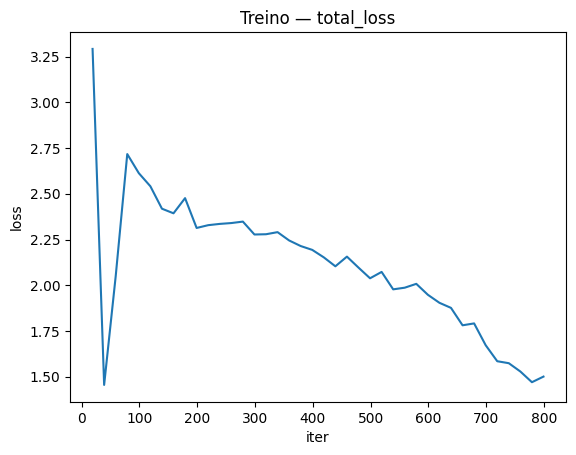

✅ APs (última avaliação):
  bbox/AP: 22.131
  bbox/AP50: 32.962
  bbox/AP75: 26.502
📦 Pesos: /content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609/model_final.pth
⚙️ Config: /content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609/config.yaml


In [10]:
# === ETAPA 4 — Relatório rápido do treino ====================================
import os, json, re
import matplotlib.pyplot as plt

RUN_DIR = "/content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609"  # trocar quando mudar a execução do frcnn_run
metrics_path = os.path.join(RUN_DIR, "metrics.json")
assert os.path.exists(metrics_path), f"metrics.json não encontrado em {metrics_path}"

# 1) Carrega todos os registros do metrics.json
metrics = [json.loads(l) for l in open(metrics_path) if l.strip()]

# 2) Último snapshot (print leve)
last = metrics[-1]
show_keys = []
for k,v in last.items():
    if isinstance(v,(int,float)) and ("AP" in k or k in ["iteration","total_loss","time"]):
        show_keys.append((k, round(v,4)))
print("📊 Último registro:", dict(show_keys))

# 3) Melhor perda (total_loss) e iteração
losses = [(m["iteration"], m.get("total_loss")) for m in metrics if "total_loss" in m]
best_it, best_loss = min(losses, key=lambda x: x[1])
print(f"🏅 Melhor total_loss: {best_loss:.3f} @ it {best_it}")

# 4) Curva simples de perda
its = [i for i,_ in losses]
vals = [l for _,l in losses]
plt.figure()
plt.plot(its, vals)
plt.title("Treino — total_loss")
plt.xlabel("iter")
plt.ylabel("loss")
plt.show()

# 5) APs (se houve avaliação durante o treino)
aps = {}
for m in metrics[::-1]:
    for k,v in m.items():
        if isinstance(v,(int,float)) and re.match(r"(bbox/)?AP", k):
            aps[k] = v
    if aps:
        break
if aps:
    print("✅ APs (última avaliação):")
    for k in sorted(aps):
        print(f"  {k}: {aps[k]:.3f}")
else:
    print("ℹ️ Sem APs no metrics.json (talvez avaliação estava desativada).")

# 6) Onde estão pesos e config
print("📦 Pesos:", os.path.join(RUN_DIR, "model_final.pth"))
print("⚙️ Config:", os.path.join(RUN_DIR, "config.yaml"))
# =============================================================================


ETAPA 5 — Avaliação + inferência rápida

recalcula as classes do train (mesma ordem do treino),

registra o test com essas classes,

carrega model_final.pth e roda AP / AP50 no test,

salva 12 imagens com predições em .../outputs/infer_samples.

📁 VOC_ROOT: /content/stride_cache/VOC2007
📁 RUN_DIR : /content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609
[10/01 01:41:44 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609/model_final.pth ...
📚 Registrado (FORÇADO): arch_voc_test_anyext_FIXED_1759282905
[10/01 01:41:45 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[10/01 01:41:45 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[10/01 01:41:45 d2.data.common]: Serializing 400 elements to byte tensors and concatenating them all ...
[10/01 01:41:45 d2.data.common]: Serialized dataset takes 0.40 MiB
[10/01 01:41:45 d2.evaluation.evaluator]: Start inference on 400 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


[10/01 01:41:50 d2.evaluation.evaluator]: Inference done 11/400. Dataloading: 0.1871 s/iter. Inference: 0.1203 s/iter. Eval: 0.0010 s/iter. Total: 0.3085 s/iter. ETA=0:01:59
[10/01 01:41:57 d2.evaluation.evaluator]: Inference done 35/400. Dataloading: 0.1417 s/iter. Inference: 0.1311 s/iter. Eval: 0.0017 s/iter. Total: 0.2752 s/iter. ETA=0:01:40
[10/01 01:42:02 d2.evaluation.evaluator]: Inference done 50/400. Dataloading: 0.1633 s/iter. Inference: 0.1299 s/iter. Eval: 0.0017 s/iter. Total: 0.2956 s/iter. ETA=0:01:43
[10/01 01:42:07 d2.evaluation.evaluator]: Inference done 65/400. Dataloading: 0.1727 s/iter. Inference: 0.1315 s/iter. Eval: 0.0018 s/iter. Total: 0.3067 s/iter. ETA=0:01:42
[10/01 01:42:12 d2.evaluation.evaluator]: Inference done 80/400. Dataloading: 0.1793 s/iter. Inference: 0.1305 s/iter. Eval: 0.0017 s/iter. Total: 0.3122 s/iter. ETA=0:01:39
[10/01 01:42:17 d2.evaluation.evaluator]: Inference done 101/400. Dataloading: 0.1666 s/iter. Inference: 0.1279 s/iter. Eval: 0.00

/usr/local/lib/python3.12/dist-packages/detectron2/evaluation/pascal_voc_evaluation.py:294: RuntimeWarning: invalid value encountered in divide
  rec = tp / float(npos)


💾 metrics salvo em: /content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609/metrics_arch_voc_test_anyext_FIXED_1759282905_20251001-014322.json

🎯 RESULTADO FINAL
- Run     : /content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609
- Dataset : TEST (arch_voc_test_anyext_FIXED_1759282905)
- mAP     : AP=22.186 | AP50=31.833 | AP75=27.452

🖼️ Mostrando 6 amostras (score ≥ 0.50)…


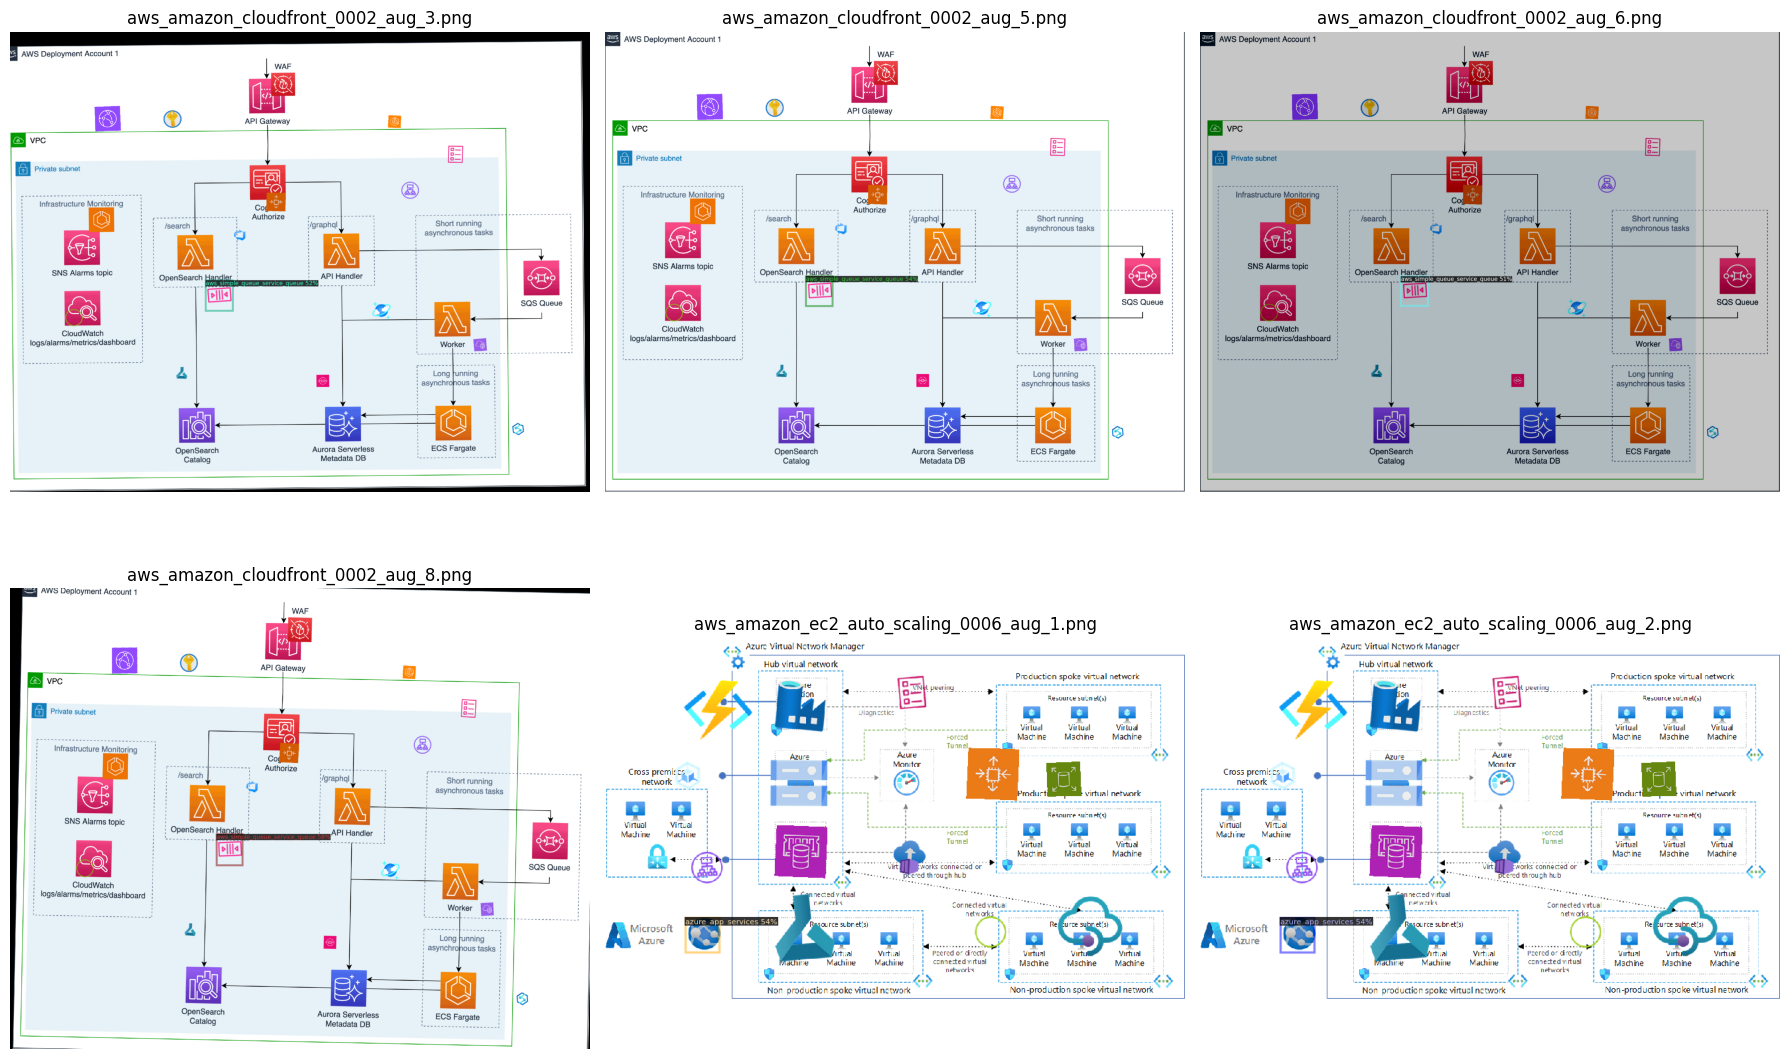

In [11]:
# ===================== ETAPA 5 (AVALIAR + EXIBIR) =====================
import os, re, time, json, glob, math, xml.etree.ElementTree as ET
from typing import List
import cv2
import numpy as np
import matplotlib.pyplot as plt

from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.data import DatasetCatalog, MetadataCatalog, build_detection_test_loader
from detectron2.structures import BoxMode
from detectron2.evaluation import PascalVOCDetectionEvaluator, inference_on_dataset
from detectron2.utils.visualizer import Visualizer, ColorMode

# -------- paths / params --------
VOC_ROOT = "/content/stride_cache/VOC2007"
RUN_DIR  = "/content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609"  # <-- ajuste se preciso
SAMPLES_TO_SHOW = 6
SCORE_THRESH_VIS = 0.50

print(f"📁 VOC_ROOT: {VOC_ROOT}")
print(f"📁 RUN_DIR : {RUN_DIR}")

# -------- helpers --------
def _exists_any(path_no_ext: str, exts=(".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")):
    for e in exts:
        p = path_no_ext + e
        if os.path.isfile(p):
            return p
    # fallback: busca recursiva
    base = os.path.basename(path_no_ext)
    jpeg_dir = os.path.join(os.path.dirname(path_no_ext))
    for e in exts:
        cand = glob.glob(os.path.join(jpeg_dir, "**", base + e), recursive=True)
        if cand:
            return cand[0]
    return None

def _read_xml_boxes(xml_path: str):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)
    anns = []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        difficult = int(obj.findtext("difficult", default="0"))
        bnd = obj.find("bndbox")
        x1 = float(bnd.find("xmin").text); y1 = float(bnd.find("ymin").text)
        x2 = float(bnd.find("xmax").text); y2 = float(bnd.find("ymax").text)
        anns.append(dict(name=name, bbox=[x1, y1, x2, y2], difficult=difficult))
    return w, h, anns

def _load_class_list_from_train(cfg):
    train_name = cfg.DATASETS.TRAIN[0]
    classes = MetadataCatalog.get(train_name).thing_classes
    assert classes and len(classes) == cfg.MODEL.ROI_HEADS.NUM_CLASSES, "Falha ao obter classes do treino."
    return list(classes)

def register_voc_anyext_fixed(name: str, voc_root: str, split: str, classes_train: List[str]):
    # sempre re-registra (para garantir image_id correto)
    if name in DatasetCatalog.list():
        DatasetCatalog.remove(name)

    imgset_path = os.path.join(voc_root, "ImageSets", "Main", f"{split}.txt")
    assert os.path.isfile(imgset_path), f"Split '{split}' não encontrado: {imgset_path}"

    with open(imgset_path, "r") as f:
        ids = [x.strip() for x in f.readlines() if x.strip()]

    id_to_idx = {c: i for i, c in enumerate(classes_train)}

    def _loader():
        dicts = []
        missing_imgs = 0
        for i, id_ in enumerate(ids):
            xml_path = os.path.join(voc_root, "Annotations", id_ + ".xml")
            img_no_ext = os.path.join(voc_root, "JPEGImages", id_)
            img_path = _exists_any(img_no_ext)
            if not img_path:
                missing_imgs += 1
                continue

            W, H, anns = _read_xml_boxes(xml_path)
            rec = {
                "file_name": img_path,
                "image_id": id_,                   # <-- **ESSENCIAL**: usar o ID textual do split!
                "height": H,
                "width":  W,
                "annotations": []
            }
            for a in anns:
                if a["name"] not in id_to_idx:
                    continue
                rec["annotations"].append({
                    "bbox": a["bbox"],
                    "bbox_mode": BoxMode.XYXY_ABS,
                    "category_id": id_to_idx[a["name"]],
                    "iscrowd": 0,
                    "difficult": int(a["difficult"]),
                })
            dicts.append(rec)
        if missing_imgs:
            print(f"⚠️ Imagens ausentes (não encontradas no disco): {missing_imgs}")
        return dicts

    DatasetCatalog.register(name, _loader)
    MetadataCatalog.get(name).set(
        thing_classes=classes_train,
        dirname=voc_root,
        split=split,
        year=2007,                # protocolo da métrica VOC (não é o ano do dataset)
        evaluator_type="pascal_voc",
    )
    print(f"📚 Registrado (FORÇADO): {name}")

# -------- 1) cfg + modelo --------
cfg = get_cfg()
cfg.merge_from_file(os.path.join(RUN_DIR, "config.yaml"))
cfg.MODEL.WEIGHTS = os.path.join(RUN_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.05  # baixo para avaliação
predictor = DefaultPredictor(cfg)

# -------- 2) (re)registrar split FIXED com image_id correto --------
classes_train = _load_class_list_from_train(cfg)
eval_name = f"arch_voc_test_anyext_FIXED_{int(time.time())}"   # sempre um novo FIXED "bom"
register_voc_anyext_fixed(eval_name, VOC_ROOT, "test", classes_train)

# -------- 3) avaliação --------
evaluator = PascalVOCDetectionEvaluator(eval_name)
loader = build_detection_test_loader(cfg, eval_name)
metrics = inference_on_dataset(predictor.model, loader, evaluator)

# (opcional) salvar métricas em JSON
stamp = time.strftime("%Y%m%d-%H%M%S")
metrics_path = os.path.join(RUN_DIR, f"metrics_{eval_name}_{stamp}.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=lambda o: float(o))
print(f"💾 metrics salvo em: {metrics_path}")

print("\n🎯 RESULTADO FINAL")
print(f"- Run     : {RUN_DIR}")
print(f"- Dataset : TEST ({eval_name})")
b = metrics["bbox"]
print(f"- mAP     : AP={float(b['AP']):.3f} | AP50={float(b['AP50']):.3f} | AP75={float(b['AP75']):.3f}")

# -------- 4) exibição --------
meta = MetadataCatalog.get(eval_name)
ds = DatasetCatalog.get(eval_name)
n_show = min(SAMPLES_TO_SHOW, len(ds))
print(f"\n🖼️ Mostrando {n_show} amostras (score ≥ {SCORE_THRESH_VIS:.2f})…")

cols = 3
rows = math.ceil(n_show / cols)
plt.figure(figsize=(cols*6, rows*6))

shown = 0
i = 0
while shown < n_show and i < len(ds):
    d = ds[i]; i += 1
    im = cv2.imread(d["file_name"])
    out = predictor(im)["instances"].to("cpu")

    # filtra por score para visual
    if "scores" in out.get_fields():
        keep = out.scores >= SCORE_THRESH_VIS
        out = out[keep]

    # pula imagens sem nenhuma predição acima do limiar, para mostrar só “com caixas”
    if len(out) == 0:
        continue

    vis = Visualizer(im[:, :, ::-1], metadata=meta, scale=0.8, instance_mode=ColorMode.IMAGE)
    vis = vis.draw_instance_predictions(out)

    plt.subplot(rows, cols, shown+1)
    plt.imshow(vis.get_image())
    plt.title(os.path.basename(d["file_name"]))
    plt.axis("off")
    shown += 1

plt.tight_layout()
plt.show()
# ===================== FIM ETAPA 5 =====================


ETAPA 6

Execução da avaliação do modelo e geração de relatorio STRIDE e principais vulnerabilidades.

📁 RUN_DIR : /content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609
🖼️ IMAGEM  : /content/drive/MyDrive/stride_mvp/arquitetura_teste_modelo.png
🎚️ THR     : 0.45
[10/01 02:01:37 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609/model_final.pth ...
🔤 Classes: 93

🖼️ Detecções mostradas (limiar efetivo: 0.20; n=2) — abaixo:


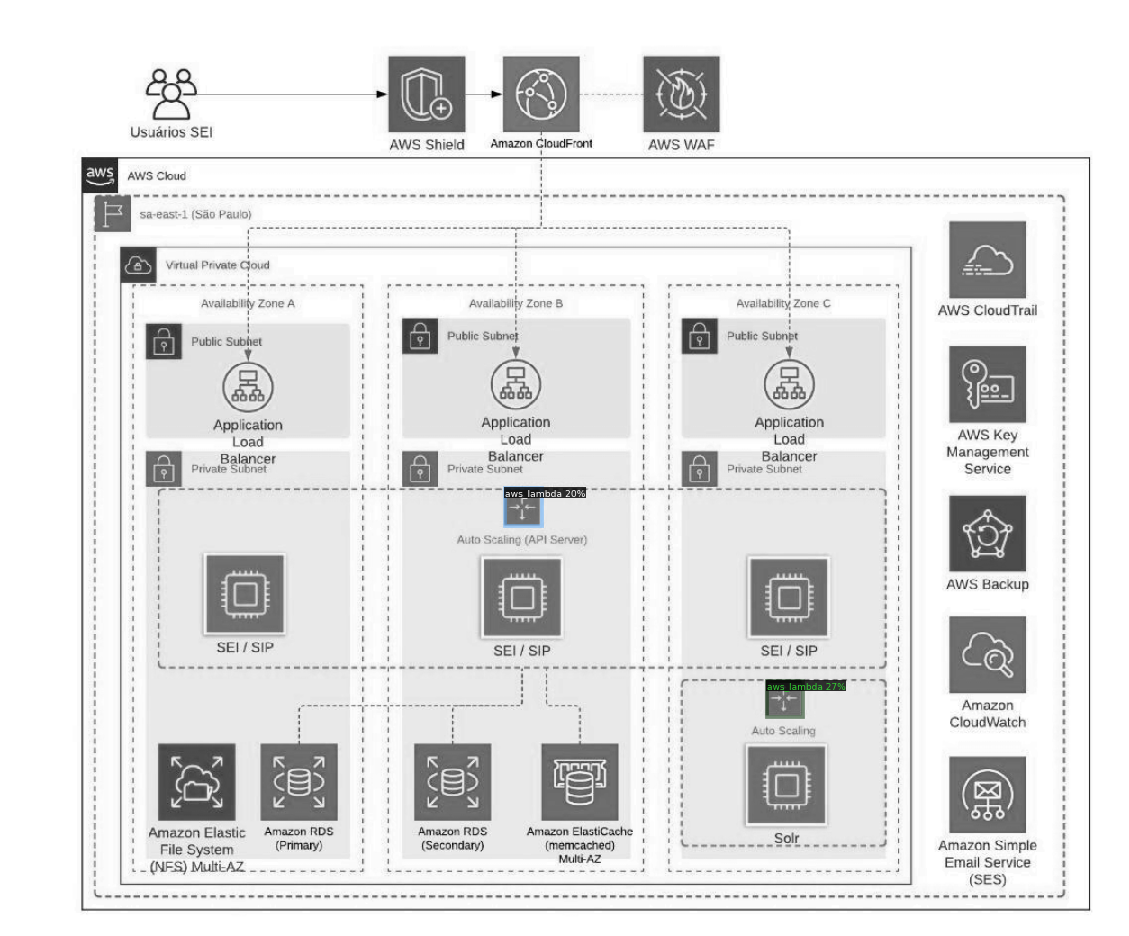


# Relatório de Modelagem de Ameaças (STRIDE)
**Imagem:** `arquitetura_teste_modelo.png`  |  **Thr pedido:** 0.45  |  **Thr usado:** 0.2

## SERVER — 2
- Classes: aws_lambda
- S: Spoofing serviço
- T: RCE/serviço vuln.
- R: Repúdio sem logs
- I: Patches faltando
- D: SYN-flood
- E: Exfiltração
- Mitigações: Hardening, FW/SG mínimo, EDR/HIDS

## JSON do relatório:
{
  "image": "/content/drive/MyDrive/stride_mvp/arquitetura_teste_modelo.png",
  "run_dir": "/content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609",
  "threshold_requested": 0.45,
  "threshold_used": 0.2,
  "raw_detections": 17,
  "num_detections_shown": 2,
  "components": [
    {
      "class_id": 34,
      "class_name": "aws_lambda",
      "type": "server",
      "score": 0.26649999618530273,
      "bbox_xyxy": [
        851.7808227539062,
        757.5297241210938,
        892.762939453125,
        797.1561889648438
      ],
      "stride": {
        "S": [
          "Spoofing serviço"
        ],
        "T": [
   

In [16]:
# ==== ETAPA 6 (revisada): Detecção + STRIDE com fallback de threshold ====
import os, json, re, cv2, torch, numpy as np
from google.colab.patches import cv2_imshow

from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.structures import Boxes, Instances

# ------------------------------
# CONFIG
# ------------------------------
RUN_DIR     = "/content/drive/MyDrive/stride_mvp/workdir/frcnn_run_1759281609"  # << ajuste se preciso
IMAGE_PATH  = "/content/drive/MyDrive/stride_mvp/arquitetura_teste_modelo.png"  # << ajuste se preciso
THRESHOLD   = 0.45
FALLBACKS   = [0.30, 0.20, 0.10, 0.05]  # degraus automáticos
TOP_N_SHOW  = 12                        # mostra top-N mesmo se abaixo do limiar
SAVE_JSON   = True

# ------------------------------
# Classes helpers
# ------------------------------
def try_load_classes(run_dir):
    for fname in ["classes.json", "thing_classes.json", "classes.txt"]:
        fpath = os.path.join(run_dir, fname)
        if os.path.isfile(fpath):
            try:
                if fname.endswith(".json"):
                    with open(fpath, "r", encoding="utf-8") as f:
                        data = json.load(f)
                    if isinstance(data, list) and all(isinstance(x, str) for x in data):
                        return data
                else:
                    with open(fpath, "r", encoding="utf-8") as f:
                        lines = [ln.strip() for ln in f if ln.strip()]
                    if lines:
                        return lines
            except Exception:
                pass
    # fallback: variável global CLASSES (se existir)
    tc = globals().get("CLASSES", None)
    if isinstance(tc, (list, tuple)) and all(isinstance(x, str) for x in tc):
        return list(tc)
    return None

def ensure_thing_classes(thing_classes, num_classes):
    if (not thing_classes) or (len(thing_classes) != num_classes):
        return [f"class_{i}" for i in range(num_classes)]
    return thing_classes

# ------------------------------
# STRIDE heuristics
# ------------------------------
STRIDE_KB = {
    "user": {"S":["Engenharia social","Sequestro de sessão"],"T":["Escalada de privilégios","Auth fraca"],"R":["Repúdio sem logs"],"I":["XSS/inputs"],"D":["DoS por requisições"],"E":["Exposição de PII"],"mitig":["MFA","Sessão segura","Logs/auditoria"]},
    "api": {"S":["Spoofing de tokens"],"T":["Broken Auth/BOLA"],"R":["Repúdio sem rastreio"],"I":["Injeção"],"D":["Abuso rate-limit"],"E":["Dados sensíveis"],"mitig":["OAuth2/OIDC","RBAC/ABAC","WAF/API GW","Validação de entrada"]},
    "server": {"S":["Spoofing serviço"],"T":["RCE/serviço vuln."],"R":["Repúdio sem logs"],"I":["Patches faltando"],"D":["SYN-flood"],"E":["Exfiltração"],"mitig":["Hardening","FW/SG mínimo","EDR/HIDS"]},
    "database": {"S":["Credenciais fracas"],"T":["SQLi/NoSQLi"],"R":["Sem auditoria"],"I":["Integridade comprometida"],"D":["Lock/DoS"],"E":["Dump sem criptografia"],"mitig":["Secrets manager","Least privilege","TDE+TLS","Queries parametrizadas"]},
    "storage": {"S":["Chaves expostas"],"T":["Bucket público"],"R":["Sem logs de acesso"],"I":["Overwrite indevido"],"D":["Listagem massiva"],"E":["Exposição de objetos"],"mitig":["Bloquear público","Criptografia","Access Analyzer"]},
    "network": {"S":["ARP/DNS spoofing"],"T":["Quebra segmentação"],"R":["Sem flow logs"],"I":["MITM"],"D":["DDoS"],"E":["Sem TLS/MTLS"],"mitig":["Segmentação","MTLS/IDS/WAF","Anti-DDoS"]},
    "queue": {"S":["Credenciais de fila"],"T":["Mensagens maliciosas"],"R":["Sem rastreio"],"I":["Duplicação sem idempotência"],"D":["Backlog/DoS"],"E":["Mensagem sensível"],"mitig":["Auth por tópico","Idempotência/DLQ","Criptografia"]},
    "monitoring": {"S":["Agente spoofado"],"T":["Injeção em collector"],"R":["Sem trilha assinada"],"I":["Telemetria adulterada"],"D":["Coleta excessiva"],"E":["Logs com PII"],"mitig":["Assinatura agentes","RBAC observ.","Sanitização"]},
    "generic": {"S":["Spoofing"],"T":["Quebra de auth"],"R":["Sem auditoria"],"I":["Input inválido"],"D":["DoS"],"E":["Exposição"],"mitig":["RBAC/ABAC","Validação","Criptografia","Observabilidade"]},
}
KEYWORDS_TO_TYPE = [
    (r"user|usuario|client", "user"),
    (r"\bapi\b|gateway|apigateway|apim|endpoint", "api"),
    (r"db|database|sql|cosmos|dynamo|postgres|mysql|mongo", "database"),
    (r"s3|blob|storage|bucket|filesystem|efs|disk|block", "storage"),
    (r"vpc|subnet|fw|firewall|waf|nat|vnet|network|cloudfront|cdn", "network"),
    (r"queue|pubsub|kafka|mq|service\s*bus|sqs|sns|event", "queue"),
    (r"monitor|cloudwatch|application\s*insights|log", "monitoring"),
    (r"vm|compute|ec2|aks|eks|gke|app\s*service|function|lambda|container|kubernetes|server", "server"),
]
def normalize_name(x): return re.sub(r"[^a-z0-9_]+","_",x.lower()).strip("_")
def class_to_type(class_name):
    n = normalize_name(class_name)
    for pat, t in KEYWORDS_TO_TYPE:
        if re.search(pat, n): return t
    return "generic"

# ------------------------------
# Model loading
# ------------------------------
def load_model(run_dir):
    cfg_path = os.path.join(run_dir, "config.yaml")
    wt_path  = os.path.join(run_dir, "model_final.pth")
    assert os.path.isfile(cfg_path), f"config.yaml não encontrado: {cfg_path}"
    assert os.path.isfile(wt_path),  f"model_final.pth não encontrado: {wt_path}"
    cfg = get_cfg()
    cfg.merge_from_file(cfg_path)
    cfg.MODEL.WEIGHTS = wt_path
    # Deixa o limiar interno baixo; vamos filtrar manualmente
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.05
    predictor = DefaultPredictor(cfg)
    try:
        num_classes = int(cfg.MODEL.ROI_HEADS.NUM_CLASSES)
    except Exception:
        num_classes = getattr(predictor.model.roi_heads.box_predictor, "num_classes", None)
        if num_classes is None:
            raise RuntimeError("Não foi possível determinar NUM_CLASSES.")
    return cfg, predictor, num_classes

# ------------------------------
# Core
# ------------------------------
def run_stride(image_path, run_dir, threshold, fallbacks, top_n_show, save_json):
    assert os.path.isfile(image_path), f"Imagem não encontrada: {image_path}"
    print(f"📁 RUN_DIR : {run_dir}")
    print(f"🖼️ IMAGEM  : {image_path}")
    print(f"🎚️ THR     : {threshold}")

    cfg, predictor, num_classes = load_model(run_dir)
    thing_classes = ensure_thing_classes(try_load_classes(run_dir), num_classes)
    print(f"🔤 Classes: {len(thing_classes)}")

    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    assert img is not None, f"cv2.imread falhou: {image_path}"

    with torch.no_grad():
        outputs = predictor(img)

    inst_all = outputs["instances"].to("cpu")
    scores_all  = inst_all.scores.numpy() if inst_all.has("scores") else np.zeros(0, np.float32)
    classes_all = inst_all.pred_classes.numpy().astype(int) if inst_all.has("pred_classes") else np.zeros(0, np.int32)
    boxes_all   = inst_all.pred_boxes.tensor.numpy() if inst_all.has("pred_boxes") else np.zeros((0,4), np.float32)

    # ordena por score desc (útil pro top-N)
    order = np.argsort(-scores_all) if len(scores_all) else np.array([], dtype=int)
    scores_all, classes_all, boxes_all = scores_all[order], classes_all[order], boxes_all[order]

    # aplica threshold adaptativo
    tried = [threshold] + list(fallbacks)
    used_thr = None
    scores, classes, boxes = np.array([]), np.array([]), np.zeros((0,4))
    for thr in tried:
        keep = scores_all >= float(thr)
        if keep.sum() > 0:
            used_thr = thr
            scores, classes, boxes = scores_all[keep], classes_all[keep], boxes_all[keep]
            break
    if used_thr is None:  # nada acima de 0.05: ainda mostramos top-N raw
        used_thr = threshold
        scores, classes, boxes = scores_all[:top_n_show], classes_all[:top_n_show], boxes_all[:top_n_show]

    # monta Instances pra desenhar
    draw_inst = Instances(image_size=img.shape[:2])
    if len(boxes) > 0:
        draw_inst.pred_boxes   = Boxes(torch.tensor(boxes, dtype=torch.float32))
        draw_inst.scores       = torch.tensor(scores, dtype=torch.float32)
        draw_inst.pred_classes = torch.tensor(classes, dtype=torch.int64)
    else:
        draw_inst.pred_boxes   = Boxes(torch.zeros((0,4), dtype=torch.float32))
        draw_inst.scores       = torch.zeros((0,), dtype=torch.float32)
        draw_inst.pred_classes = torch.zeros((0,), dtype=torch.int64)

    viz = Visualizer(img[:, :, ::-1], metadata={"thing_classes": thing_classes},
                     scale=0.9, instance_mode=ColorMode.IMAGE_BW)
    viz = viz.draw_instance_predictions(draw_inst)
    vis_img = viz.get_image()[:, :, ::-1]
    print(f"\n🖼️ Detecções mostradas (limiar efetivo: {used_thr:.2f}; n={len(scores)}) — abaixo:")
    cv2_imshow(vis_img)

    # monta componentes
    components = []
    for s, c, b in zip(scores, classes, boxes):
        cname = thing_classes[c] if 0 <= int(c) < len(thing_classes) else f"class_{int(c)}"
        ctype = class_to_type(cname)
        components.append({
            "class_id": int(c),
            "class_name": cname,
            "type": ctype,
            "score": float(np.round(s, 4)),
            "bbox_xyxy": [float(x) for x in b.tolist()],
        })

    # anexa STRIDE
    def stride_entry(ctype):
        kb = STRIDE_KB.get(ctype, STRIDE_KB["generic"])
        return {"S":kb["S"],"T":kb["T"],"R":kb["R"],"I":kb["I"],"D":kb["D"],"E":kb["E"],"mitigations":kb["mitig"]}
    for comp in components:
        comp["stride"] = stride_entry(comp["type"])

    report = {
        "image": image_path,
        "run_dir": run_dir,
        "threshold_requested": float(threshold),
        "threshold_used": float(used_thr),
        "raw_detections": int(len(scores_all)),
        "num_detections_shown": int(len(components)),
        "components": components,
    }

    print("\n# Relatório de Modelagem de Ameaças (STRIDE)")
    print(f"**Imagem:** `{os.path.basename(image_path)}`  |  **Thr pedido:** {threshold}  |  **Thr usado:** {used_thr}")
    if not components:
        print("> Nenhuma detecção (mostramos top-N vazios).")
    else:
        by_type = {}
        for comp in components: by_type.setdefault(comp["type"], []).append(comp)
        for t, comps in by_type.items():
            names = ", ".join(sorted({c['class_name'] for c in comps}))
            print(f"\n## {t.upper()} — {len(comps)}")
            print(f"- Classes: {names}")
            kb = STRIDE_KB.get(t, STRIDE_KB["generic"])
            print(f"- S: {', '.join(kb['S'])}")
            print(f"- T: {', '.join(kb['T'])}")
            print(f"- R: {', '.join(kb['R'])}")
            print(f"- I: {', '.join(kb['I'])}")
            print(f"- D: {', '.join(kb['D'])}")
            print(f"- E: {', '.join(kb['E'])}")
            print(f"- Mitigações: {', '.join(kb['mitig'])}")

    print("\n## JSON do relatório:")
    print(json.dumps(report, ensure_ascii=False, indent=2))
    if SAVE_JSON:
        out_json = os.path.join(run_dir, "stride_report.json")
        with open(out_json, "w", encoding="utf-8") as f:
            json.dump(report, f, ensure_ascii=False, indent=2)
        print(f"\n💾 Relatório salvo em: {out_json}")

# ------------------------------
# RUN
# ------------------------------
run_stride(IMAGE_PATH, RUN_DIR, THRESHOLD, FALLBACKS, TOP_N_SHOW, SAVE_JSON)
